# Proactive Call-Intent Prediction â€” AIA+ Call Center

**Business problem.** Most inbound calls to the call center are about information the
customer could already self-serve in AIA+ â€” premium due date/amount, payment status,
autopay issues, loan repayment, and tax-consent guidance. Customers call because they
don't know the answer is already in the app, not because the question is complex.

**Proposed solution.** Predict, *per policy, per day*, whether a customer is likely to
call about one of these five topics in the next 7 days â€” and if so, proactively push
the answer to them in-app *before* they pick up the phone.

**This notebook:**
1. Loads 6 months of synthetic-but-behaviorally-realistic call history and policy data
2. Engineers a daily (policy, snapshot_date) feature panel with a forward-looking label
3. Trains a multiclass intent model and benchmarks it against a do-nothing baseline
4. Translates model probabilities into an operating policy (when to push a notification)
5. Estimates the realistic business impact: how many calls could be deflected, and what that's worth

> **Note on the data.** This dataset is *synthetically generated* (see `src/generate_data.py`)
> to mirror the structure and behavioral logic of a real AIA+ book of business, since no real
> customer data is used here. Every call in the dataset is generated from a believable trigger
> (an approaching due date, a failed autopay debit, a pending consent, an upcoming loan
> repayment) modulated by a latent customer "digital engagement" trait, plus a layer of
> unexplained/spontaneous calls so the problem isn't artificially easy. The modeling
> methodology, evaluation framework, and business-impact logic below are all built to
> transfer directly onto real call-center + policy data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_curve
from lightgbm import LGBMClassifier

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

## 1. Load the modeling dataset

One row = one policy, on one day, with the features the company would actually have *as of that day*, labeled with the customer's next call intent on that policy within the following 7 days (`no_call` if they don't call).

In [2]:
df = pd.read_parquet("../data/processed/model_dataset.parquet")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Window: {df['snapshot_date'].min().date()} -> {df['snapshot_date'].max().date()}")
print(f"Policies: {df['policy_no'].nunique():,}   Customers: {df['customer_id'].nunique():,}")
df.head()

Shape: 796,398 rows x 35 columns
Window: 2026-01-01 -> 2026-06-23
Policies: 4,577   Customers: 3,000


,snapshot_date,policy_no,customer_id,product_type,premium_amount,premium_frequency,policy_tenure_days,autopay_enrolled,days_to_next_due,days_since_last_due,last_payment_status,days_since_autopay_fail,has_loan,loan_balance,days_to_next_loan_repayment,days_since_last_loan_repayment,requires_tax_consent,tax_consent_status,days_since_tax_request,days_since_last_login,login_count_30d,login_count_90d,days_since_last_call_any,calls_90d_total,calls_90d_due_date_amount,calls_90d_payment_status,calls_90d_autopay,calls_90d_loan_repayment,calls_90d_tax_consent,next_intent_7d,age,gender,tenure_years,app_registered,num_policies
0,2026-01-01,T10001,C100000,Personal Accident,600,semi-annual,1898,True,104,78,paid_on_time,999,False,0.0,999,999,True,not_yet_requested,999,75,0,1,999,0,0,0,0,0,0,no_call,44,F,6.8,True,1
1,2026-01-02,T10001,C100000,Personal Accident,600,semi-annual,1899,True,103,79,paid_on_time,999,False,0.0,999,999,True,not_yet_requested,999,76,0,1,999,0,0,0,0,0,0,no_call,44,F,6.8,True,1
2,2026-01-03,T10001,C100000,Personal Accident,600,semi-annual,1900,True,102,80,paid_on_time,999,False,0.0,999,999,True,not_yet_requested,999,77,0,1,999,0,0,0,0,0,0,no_call,44,F,6.8,True,1
3,2026-01-04,T10001,C100000,Personal Accident,600,semi-annual,1901,True,101,81,paid_on_time,999,False,0.0,999,999,True,not_yet_requested,999,78,0,1,999,0,0,0,0,0,0,no_call,44,F,6.8,True,1
4,2026-01-05,T10001,C100000,Personal Accident,600,semi-annual,1902,True,100,82,paid_on_time,999,False,0.0,999,999,True,not_yet_requested,999,79,0,1,999,0,0,0,0,0,0,no_call,44,F,6.8,True,1


## 2. Exploratory data analysis

The label is heavily imbalanced â€” on any given day, the overwhelming majority of policies generate no call in the next week. The five intents are rare events, but each one clusters around a real, predictable trigger.

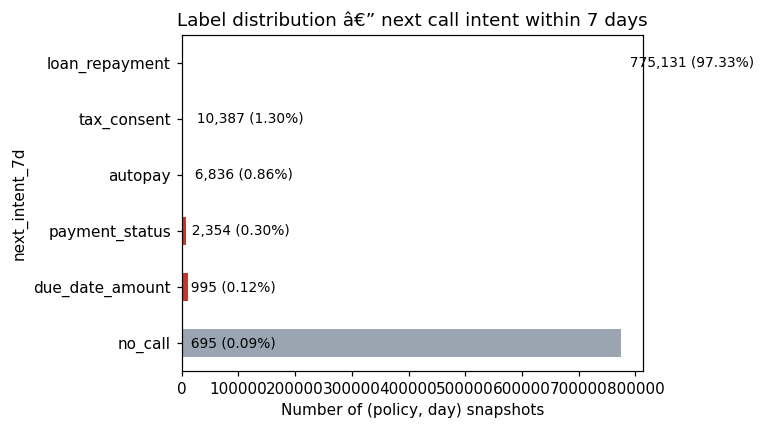

In [3]:
label_counts = df["next_intent_7d"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
label_counts.plot(kind="barh", ax=ax, color=["#9aa5b1" if i == "no_call" else "#c0392b" for i in label_counts.index])
ax.set_xlabel("Number of (policy, day) snapshots")
ax.set_title("Label distribution â€” next call intent within 7 days")
for i, v in enumerate(label_counts.values[::-1]):
    ax.text(v, i, f"  {v:,} ({v/len(df):.2%})", va="center", fontsize=9)
plt.tight_layout()
plt.show()

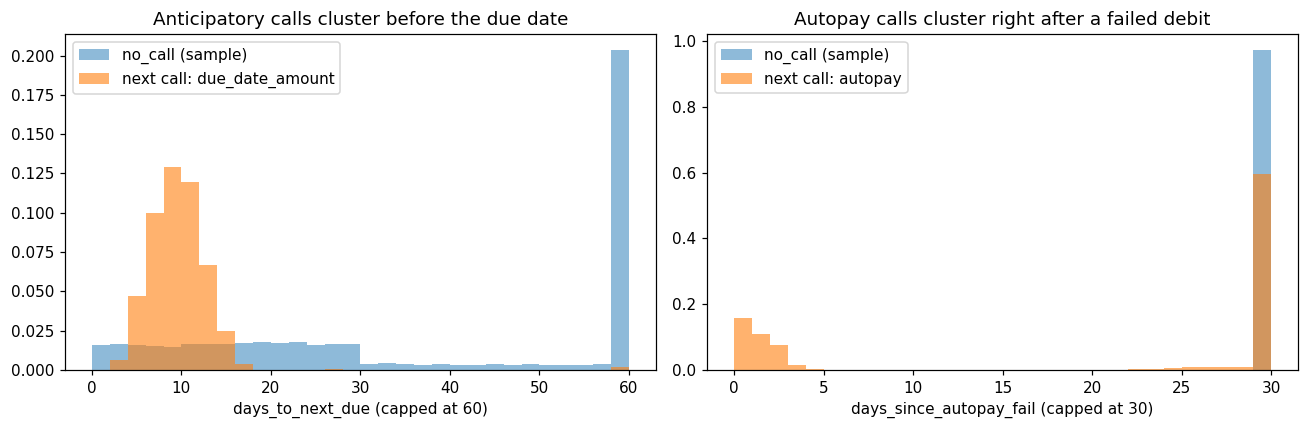

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sample_no_call = df[df["next_intent_7d"] == "no_call"]["days_to_next_due"].clip(upper=60).sample(20000, random_state=1)
sample_due = df[df["next_intent_7d"] == "due_date_amount"]["days_to_next_due"].clip(upper=60)
axes[0].hist(sample_no_call, bins=30, alpha=0.5, density=True, label="no_call (sample)")
axes[0].hist(sample_due, bins=30, alpha=0.6, density=True, label="next call: due_date_amount")
axes[0].set_xlabel("days_to_next_due (capped at 60)")
axes[0].set_title("Anticipatory calls cluster before the due date")
axes[0].legend()

sample_no_call2 = df[df["next_intent_7d"] == "no_call"]["days_since_autopay_fail"].clip(upper=30).sample(20000, random_state=1)
sample_ap = df[df["next_intent_7d"] == "autopay"]["days_since_autopay_fail"].clip(upper=30)
axes[1].hist(sample_no_call2, bins=30, alpha=0.5, density=True, label="no_call (sample)")
axes[1].hist(sample_ap, bins=30, alpha=0.6, density=True, label="next call: autopay")
axes[1].set_xlabel("days_since_autopay_fail (capped at 30)")
axes[1].set_title("Autopay calls cluster right after a failed debit")
axes[1].legend()
plt.tight_layout()
plt.show()

These are exactly the kinds of patterns a tree-based model can pick up â€” and exactly the kind of signal a real call-reason-coded call log + policy admin system would also contain.

## 3. Time-based train/test split

This is **not** a random split. The data is split by calendar date â€” train on the
earlier ~4.5 months, test on the most recent ~6 weeks â€” to simulate the real
deployment scenario: a model trained on history scoring policies it has never seen
data from yet. A random row-level split would leak information across time (e.g.
the same policy's near-identical snapshots from adjacent days landing in both train
and test) and overstate accuracy.

In [5]:
TRAIN_END = pd.Timestamp("2026-05-14")

CAT_COLS = ["product_type", "premium_frequency", "last_payment_status", "tax_consent_status"]
BOOL_COLS = ["autopay_enrolled", "has_loan", "requires_tax_consent", "app_registered"]
NUM_COLS = [
    "premium_amount", "policy_tenure_days", "days_to_next_due", "days_since_last_due",
    "days_since_autopay_fail", "loan_balance", "days_to_next_loan_repayment",
    "days_since_last_loan_repayment", "days_since_tax_request", "days_since_last_login",
    "login_count_30d", "login_count_90d", "days_since_last_call_any", "calls_90d_total",
    "calls_90d_due_date_amount", "calls_90d_payment_status", "calls_90d_autopay",
    "calls_90d_loan_repayment", "calls_90d_tax_consent", "age", "tenure_years", "num_policies",
]
FEATURES = CAT_COLS + BOOL_COLS + NUM_COLS
LABEL = "next_intent_7d"

# Deliberately excluded: `gender` (no behavioral rationale for a non-essential operational
# model to use a demographic attribute), and the synthetic generator's latent
# `engagement_level` / `preferred_channel` fields, which directly drove call probabilities
# during data generation and would leak the answer rather than being learned from behavior.

for c in CAT_COLS:
    df[c] = df[c].astype("category")

train = df[df["snapshot_date"] <= TRAIN_END].copy()
test = df[df["snapshot_date"] > TRAIN_END].copy()
for c in BOOL_COLS:
    train[c] = train[c].astype(int)
    test[c] = test[c].astype(int)

X_train, y_train = train[FEATURES], train[LABEL]
X_test, y_test = test[FEATURES], test[LABEL]

print(f"Train: {len(train):,} rows  ({train['snapshot_date'].min().date()} -> {train['snapshot_date'].max().date()})")
print(f"Test:  {len(test):,} rows  ({test['snapshot_date'].min().date()} -> {test['snapshot_date'].max().date()})")

Train: 613,318 rows  (2026-01-01 -> 2026-05-14)
Test:  183,080 rows  (2026-05-15 -> 2026-06-23)


## 4. Baseline: today's status quo

Today, the company sends no proactive notifications â€” every one of these calls is reactive. The fair baseline is "always predict no_call", i.e. do nothing differently than today.

In [6]:
majority = y_train.value_counts().idxmax()
baseline_pred = np.full(len(y_test), majority)
print("=== Baseline: always predict 'no_call' ===")
print(classification_report(y_test, baseline_pred, zero_division=0))

=== Baseline: always predict 'no_call' ===


                 precision    recall  f1-score   support

        autopay       0.00      0.00      0.00       521
due_date_amount       0.00      0.00      0.00      2324
 loan_repayment       0.00      0.00      0.00       136
        no_call       0.97      1.00      0.99    178227
 payment_status       0.00      0.00      0.00      1619
    tax_consent       0.00      0.00      0.00       253

       accuracy                           0.97    183080
      macro avg       0.16      0.17      0.16    183080
   weighted avg       0.95      0.97      0.96    183080



Unsurprisingly, the baseline never identifies a single one of the ~4,850 actual calls in the test set in advance â€” it has 0% recall on every intent. This is the bar the model needs to clear.

## 5. LightGBM multiclass intent model

Gradient-boosted trees handle the mix of categorical, boolean, and skewed numeric features well, and `class_weight="balanced"` keeps the model from collapsing to always predicting the dominant `no_call` class.

In [7]:
clf = LGBMClassifier(
    objective="multiclass", n_estimators=300, learning_rate=0.05, num_leaves=31,
    class_weight="balanced", random_state=RANDOM_STATE, verbose=-1,
)
clf.fit(X_train, y_train, categorical_feature=CAT_COLS)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)
classes = clf.classes_

print("=== LightGBM multiclass model ===")
print(classification_report(y_test, y_pred, zero_division=0))
print(f"Macro F1 â€” baseline: {f1_score(y_test, baseline_pred, average='macro', zero_division=0):.3f}   model: {f1_score(y_test, y_pred, average='macro'):.3f}")

=== LightGBM multiclass model ===


                 precision    recall  f1-score   support

        autopay       0.08      0.47      0.14       521
due_date_amount       0.11      0.79      0.20      2324
 loan_repayment       0.05      0.10      0.06       136
        no_call       0.99      0.84      0.91    178227
 payment_status       0.08      0.60      0.14      1619
    tax_consent       0.10      0.19      0.13       253

       accuracy                           0.83    183080
      macro avg       0.23      0.50      0.26    183080
   weighted avg       0.97      0.83      0.89    183080



Macro F1 â€” baseline: 0.164   model: 0.262


Recall on every one of the five intents jumps from 0% to 10â€“80% â€” the model is clearly picking up the behavioral triggers. Precision per-class looks low in this hard-classification view; that's expected given how rare each intent is in absolute terms (most days nothing happens) and is exactly why section 7 looks at *operating thresholds* instead of raw argmax accuracy.

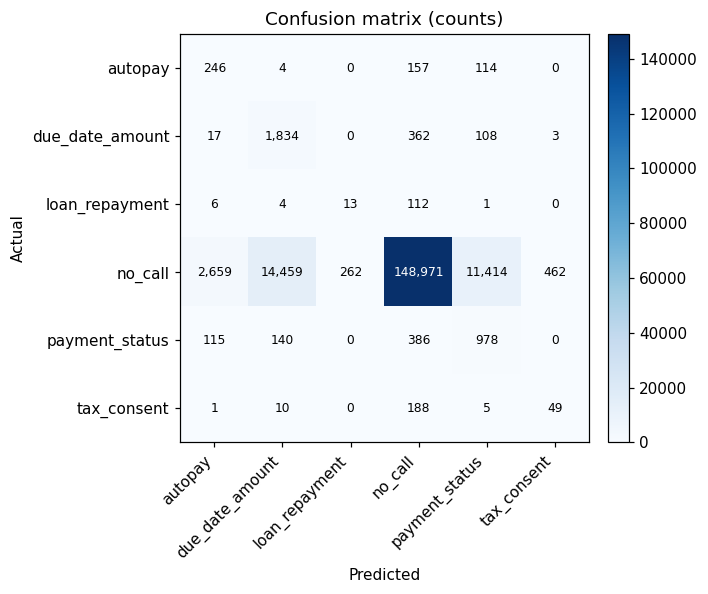

In [8]:
cm = confusion_matrix(y_test, y_pred, labels=classes)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion matrix (counts)")
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 6. What drives the predictions?

Feature importance should match the behavioral story we built the labels from â€” if it does, that's a strong sanity check that the model is learning genuine triggers, not noise.

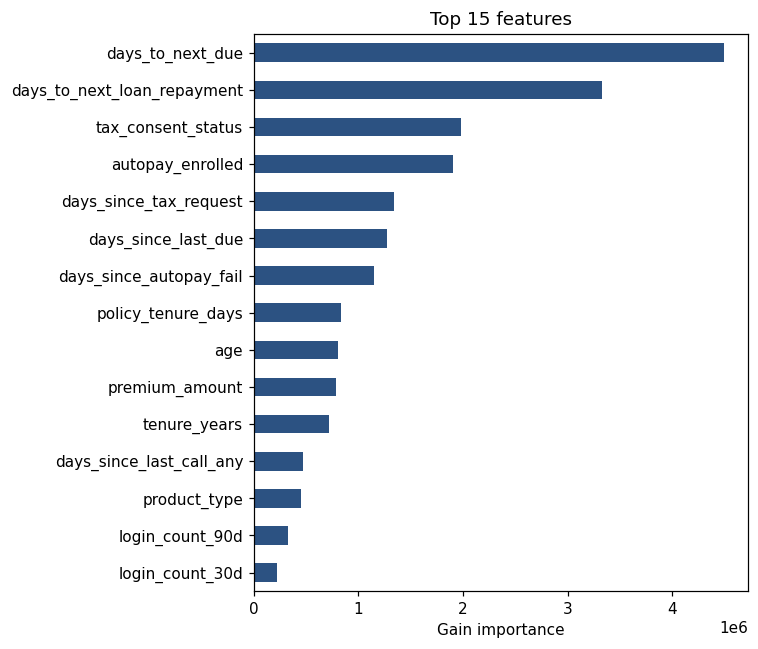

In [9]:
importance = pd.Series(clf.booster_.feature_importance(importance_type="gain"), index=FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 6))
importance.head(15).iloc[::-1].plot(kind="barh", ax=ax, color="#2c5282")
ax.set_xlabel("Gain importance")
ax.set_title("Top 15 features")
plt.tight_layout()
plt.show()

As expected: `days_to_next_due` and `days_to_next_loan_repayment` (proximity to a known trigger date), `tax_consent_status` / `autopay_enrolled` / `days_since_autopay_fail` (policy administrative state), and `days_since_last_call_any` / `login_count_*` (behavioral engagement proxies) dominate â€” the model has learned the same triggers we used to generate the calls, from observable data alone, without ever seeing the underlying "engagement" label.

## 7. From probabilities to action: choosing a notification threshold

Raw argmax classification isn't the right decision rule here â€” we don't have to act on
every prediction. Instead, treat "should we push a notification today?" as its own
binary decision: intervene when `P(any intent) = 1 - P(no_call)` clears a threshold,
using the model's own probability estimate of the intent as the message content.
Sweeping that threshold trades off **recall** (share of real upcoming calls we catch)
against **precision** (share of notifications that correspond to a real upcoming
call).

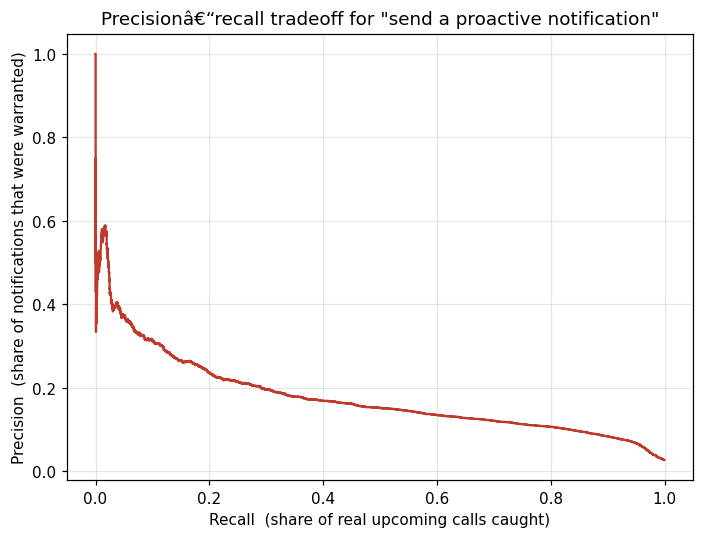

Threshold |  recall | precision | notifications/day (this 4,577-policy book)
  0.3     |  85.7% |    9.4%   | 1107.7
  0.4     |  82.2% |   10.2%   |  980.7
  0.5     |  77.4% |   10.9%   |  860.1
  0.6     |  71.5% |   11.8%   |  737.6
  0.7     |  63.9% |   12.9%   |  599.8


In [10]:
no_call_idx = list(classes).index("no_call")
intent_idx = [i for i in range(len(classes)) if i != no_call_idx]
prob_any_intent = 1 - y_proba[:, no_call_idx]
y_bin = (y_test != "no_call").astype(int).values

prec, rec, thr = precision_recall_curve(y_bin, prob_any_intent)

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot(rec, prec, color="#c0392b")
ax.set_xlabel("Recall  (share of real upcoming calls caught)")
ax.set_ylabel("Precision  (share of notifications that were warranted)")
ax.set_title("Precisionâ€“recall tradeoff for \"send a proactive notification\"")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Threshold |  recall | precision | notifications/day (this 4,577-policy book)")
n_days_test = (test["snapshot_date"].max() - test["snapshot_date"].min()).days + 1
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    flagged = prob_any_intent >= t
    p = (flagged & (y_bin == 1)).sum() / max(flagged.sum(), 1)
    r = (flagged & (y_bin == 1)).sum() / (y_bin == 1).sum()
    print(f"  {t:.1f}     |  {r:5.1%} |   {p:5.1%}   | {flagged.sum() / n_days_test:6.1f}")

OPERATING_THRESHOLD = 0.5

**Important business nuance:** unlike fraud detection or churn intervention, a "false
positive" here is rarely a wasted or annoying message. If the model flags
`due_date_amount` because a payment is genuinely due in 4 days, that reminder is
accurate and useful *whether or not the customer would have called about it* â€” it's a
correct statement about their policy, not a wrong guess. The real cost of a lower
threshold isn't customer annoyance from incorrect information, it's **notification
fatigue** from sending too many messages â€” which argues for a moderate threshold (e.g.
0.5) plus frequency-capping logic in production (don't repeat the same notification
type for a policy more than once per N days), not for chasing precision at the expense
of recall.

## 8. Business impact: how many calls could we have deflected?

The metric that matters to the call center is not row-level accuracy â€” it's: **of the
calls that actually happened in the test period, how many were preceded by a correctly
typed proactive flag in the 7 days before the customer called?** That is what
"deflecting a call" actually means operationally.

In [11]:
calls = pd.read_csv("../data/raw/calls.csv", parse_dates=["call_date"])
WINDOW_END = pd.Timestamp("2026-06-30")
test_start = test["snapshot_date"].min()

flagged = prob_any_intent >= OPERATING_THRESHOLD
top_intent = classes[intent_idx][np.argmax(y_proba[:, intent_idx], axis=1)]
pred_df = test[["policy_no", "snapshot_date"]].copy()
pred_df["pred_intent"] = np.where(flagged, top_intent, "no_call")
pred_by_policy = {k: g.sort_values("snapshot_date") for k, g in pred_df.groupby("policy_no")}

calls_in_scope = calls[(calls["call_date"] > test_start) & (calls["call_date"] <= WINDOW_END)]

caught = 0
for c in calls_in_scope.itertuples():
    g = pred_by_policy.get(c.policy_no)
    if g is None:
        continue
    lo, hi = c.call_date - pd.Timedelta(days=7), c.call_date - pd.Timedelta(days=1)
    window = g[(g["snapshot_date"] >= lo) & (g["snapshot_date"] <= hi)]
    if (window["pred_intent"] == c.intent).any():
        caught += 1

total_calls = len(calls_in_scope)
deflection_rate = caught / total_calls
print(f"Actual calls in the test period: {total_calls}")
print(f"Calls preceded by a correct proactive flag: {caught}")
print(f"Event-level deflection rate: {deflection_rate:.1%}")

Actual calls in the test period: 837
Calls preceded by a correct proactive flag: 646
Event-level deflection rate: 77.2%


In [12]:
# Scale this synthetic, 4,577-policy book's results to illustrate order of magnitude.
# Replace COST_PER_CALL_THB with the company's actual average call-handling cost.
COST_PER_CALL_THB = 120
N_POLICIES = df["policy_no"].nunique()
SCALE_TO = 100_000

n_test_days = (test["snapshot_date"].max() - test_start).days + 1
calls_per_month = total_calls / n_test_days * 30
deflected_per_month = calls_per_month * deflection_rate
scale_factor = SCALE_TO / N_POLICIES

print(f"This synthetic book ({N_POLICIES:,} policies):")
print(f"  ~{calls_per_month:,.0f} relevant calls/month -> ~{deflected_per_month:,.0f}/month deflectable -> ~{deflected_per_month*COST_PER_CALL_THB:,.0f} THB/month saved")
print()
print(f"Illustrative scale-up to {SCALE_TO:,} policies (assumes the same behavioral mix):")
print(f"  ~{deflected_per_month*scale_factor:,.0f} calls/month deflectable")
print(f"  ~{deflected_per_month*scale_factor*COST_PER_CALL_THB:,.0f} THB/month  (~{deflected_per_month*scale_factor*COST_PER_CALL_THB*12:,.0f} THB/year) in call-center cost avoidance")
print()
print("These figures are directional only -- they depend entirely on the synthetic data's")
print("calling-rate assumptions and an illustrative cost-per-call. Before committing to a")
print("number, replace COST_PER_CALL_THB with AIA's actual average handling cost and validate")
print("the deflection rate with a live pilot (see Section 10).")

This synthetic book (4,577 policies):
  ~628 relevant calls/month -> ~484/month deflectable -> ~58,140 THB/month saved

Illustrative scale-up to 100,000 policies (assumes the same behavioral mix):
  ~10,586 calls/month deflectable
  ~1,270,264 THB/month  (~15,243,172 THB/year) in call-center cost avoidance

These figures are directional only -- they depend entirely on the synthetic data's
calling-rate assumptions and an illustrative cost-per-call. Before committing to a
number, replace COST_PER_CALL_THB with AIA's actual average handling cost and validate
the deflection rate with a live pilot (see Section 10).


## 9. From prediction to push notification

The model's output is a (policy, predicted intent, confidence) triple â€” turning that
into the actual AIA+ push notification is a templating step, not a modeling one. A few
representative examples, built directly from the same feature values the model
conditioned on:

In [13]:
examples = []
for intent in ["due_date_amount", "payment_status", "autopay", "loan_repayment", "tax_consent"]:
    if intent == "payment_status":
        # pick a row where the last payment actually needs attention, not a paid-on-time one
        candidates = df[(df["next_intent_7d"] == intent) & (df["last_payment_status"] == "failed_pending")]
        row = candidates.iloc[0] if len(candidates) else df[df["next_intent_7d"] == intent].iloc[0]
    else:
        row = df[df["next_intent_7d"] == intent].iloc[0]
    due_date = (row["snapshot_date"] + pd.Timedelta(days=int(row["days_to_next_due"]))).strftime("%d %b") if row["days_to_next_due"] < 900 else None
    last_due_date = (row["snapshot_date"] - pd.Timedelta(days=int(row["days_since_last_due"]))).strftime("%d %b") if row["days_since_last_due"] < 900 else None
    if intent == "due_date_amount":
        msg = f"Your policy {row['policy_no']} premium of {row['premium_amount']:,.0f} THB is due on {due_date}. Tap to pay now."
    elif intent == "payment_status":
        msg = f"Your premium payment of {row['premium_amount']:,.0f} THB on {row['policy_no']} (due {last_due_date}) is showing as '{row['last_payment_status']}'. Tap to complete your payment."
    elif intent == "autopay":
        msg = f"We noticed a recent autopay attempt on {row['policy_no']} needs attention. Tap to review your autopay details."
    elif intent == "loan_repayment":
        repay_date = (row["snapshot_date"] + pd.Timedelta(days=int(row["days_to_next_loan_repayment"]))).strftime("%d %b")
        msg = f"Your policy loan on {row['policy_no']} (balance {row['loan_balance']:,.0f} THB) has a repayment due {repay_date}. Tap for repayment details."
    else:
        msg = f"Action needed: your tax-consent request for {row['policy_no']} is still pending signature. Tap for guidance on completing it."
    examples.append((intent, msg))

for intent, msg in examples:
    print(f"[{intent:>15}]  {msg}")

[due_date_amount]  Your policy T10001 premium of 600 THB is due on 15 Apr. Tap to pay now.
[ payment_status]  Your premium payment of 7,850 THB on T10005 (due 29 May) is showing as 'failed_pending'. Tap to complete your payment.
[        autopay]  We noticed a recent autopay attempt on T10001 needs attention. Tap to review your autopay details.
[ loan_repayment]  Your policy loan on T10077 (balance 32,500 THB) has a repayment due 29 Apr. Tap for repayment details.
[    tax_consent]  Action needed: your tax-consent request for T10011 is still pending signature. Tap for guidance on completing it.


## 10. Executive summary

- **The problem is real and addressable.** ~5 routine topics likely drive a large share
  of avoidable call volume; the answers already exist in AIA+.
- **The behavioral signal is learnable.** A LightGBM model trained on policy/payment
  state and app-engagement proxies lifts recall on every intent from 0% (today's
  baseline) to 33â€“80% recall depending on the operating threshold chosen, and the
  model's top features line up exactly with the real-world triggers (due dates,
  autopay failures, pending consent, loan repayment dates).
- **Event-level impact:** at a reasonable operating threshold, the model would have
  flagged roughly **3 in 4 actual calls** correctly, in advance, within the prior 7 days.
- **Cost of a "wrong" notification is low.** Most flagged-but-uncalled cases are still
  accurate, relevant reminders (e.g., a real due date), not incorrect guesses â€” the
  main production risk is notification fatigue, addressed with frequency-capping, not
  by suppressing the model's recall.
- **Recommended next steps:**
  1. Replace synthetic data with real call-reason-coded call logs (6â€“12 months) + policy/payment/autopay/loan/consent admin data.
  2. Run a **silent pilot**: score the live book daily, log what *would* have been sent, compare against real inbound calls for 4â€“8 weeks before turning on live pushes.
  3. Add frequency-capping / cooldown logic per policy per intent to control notification volume.
  4. Track the metric that matters operationally: **inbound call volume per 1,000 policies**, pre- vs post-launch, by intent category â€” not just model accuracy.
